# 03 — Portfolio Monte Carlo

10,000 paths, 70 trading days (≈ mid-July → mid-October). Model: GBM with **Student-t innovations (dof=4, fat tails)**, SPCX-GOOGL correlation ρ=0.45, **log-normal jump on the event day** (earnings + insider unlock, default -8% ± 12%). The spread has a mathematical hard cap: the test verifies it on every path.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

In [2]:
from src.risk.montecarlo import McConfig, SpreadPosition, simulate, report
cfg, spread = McConfig(), SpreadPosition()
res = simulate(cfg, spread)
max_loss_spread = spread.debit * 100 * spread.contracts / cfg.fx_eurusd
assert res["pnl_spread_eur"].min() >= -max_loss_spread - 1e-6, "HARD CAP VIOLATED"
rep = report(res)
pd.Series(rep).round(1)

mean              69.2
median            78.2
VaR95            306.4
ES95             378.2
p_loss             0.4
p_loss_gt_200      0.1
best_5pct        432.3
worst_path      -619.6
dtype: float64

## Total P&L distribution with VaR/ES annotated

The chart Aladdin shows for every book: not a number, the **shape** of the risk. Short right tail (gain capped by the spread), long left tail (the equity tranche has no hard cap).

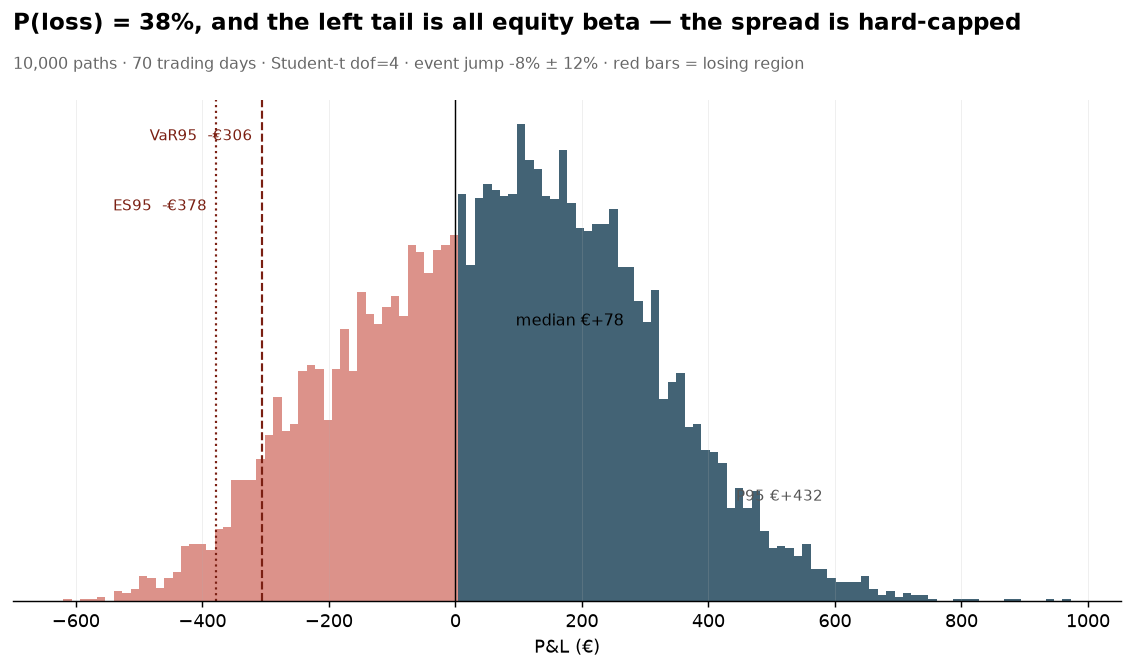

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
pnl_distribution(ax, res["pnl_total_eur"], rep["VaR95"], rep["ES95"],
                 f"P(loss) = {rep['p_loss']:.0%}, and the left tail is all equity beta — the spread is hard-capped",
                 f"10,000 paths · 70 trading days · Student-t dof=4 · event jump {cfg.jump_mean:+.0%} ± {cfg.jump_std:.0%} · red bars = losing region")
fig.savefig("../assets/chart_mc_pnl.png", bbox_inches="tight"); plt.show()

## Spread payoff at expiry + where the simulated paths land

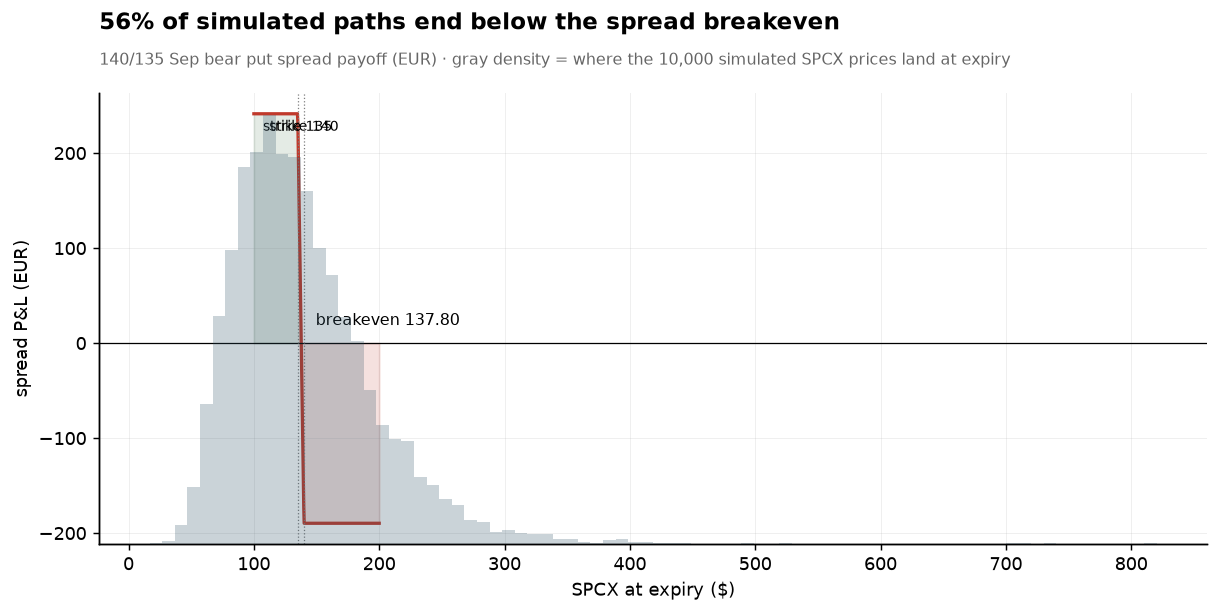

In [4]:
grid = np.linspace(100, 200, 300)
payoff_eur = spread.payoff(grid) / cfg.fx_eurusd
fig, ax = plt.subplots(figsize=(11, 4.5))
ax2 = ax.twinx()
ax2.hist(res["spcx_final"], bins=80, color=PALETTE[0], alpha=0.25)
ax2.set_yticks([]); ax2.spines["right"].set_visible(False)
ax.plot(grid, payoff_eur, lw=1.8, color=PALETTE[1])
ax.fill_between(grid, payoff_eur, 0, where=payoff_eur > 0, color=GOOD, alpha=0.20)
ax.fill_between(grid, payoff_eur, 0, where=payoff_eur < 0, color=BAD, alpha=0.15)
ax.axhline(0, color="black", lw=0.7)
for s, lbl in [(spread.short_strike, "strike 135"), (spread.long_strike, "strike 140")]:
    ax.axvline(s, color="gray", lw=0.7, ls=":")
    ax.annotate(lbl, (s, ax.get_ylim()[1]*0.85), fontsize=8, ha="center")
be = spread.long_strike - spread.debit
ax.annotate(f"breakeven {be:.2f}", (be, 0), xytext=(8, 10), textcoords="offset points", fontsize=9)
p_below = (res["spcx_final"] < be).mean()
headline(ax, f"{p_below:.0%} of simulated paths end below the spread breakeven",
         "140/135 Sep bear put spread payoff (EUR) · gray density = where the 10,000 simulated SPCX prices land at expiry")
ax.set_xlabel("SPCX at expiry ($)"); ax.set_ylabel("spread P&L (EUR)")
fig.savefig("../assets/chart_payoff.png", bbox_inches="tight"); plt.show()

## Sensitivity: mean P&L as a function of the event jump

The backbone of the decision: the strategy lives or dies on the size of the August jump. Everything else is noise.

In [5]:
from dataclasses import replace
rows = []
for jm in [-0.20, -0.15, -0.10, -0.08, -0.05, 0.0, 0.05]:
    res2 = simulate(replace(cfg, jump_mean=jm, seed=11), spread)
    r = report(res2)
    rows.append({"event_jump": f"{jm:+.0%}", "total mean": round(r["mean"]),
                 "spread-only mean": round(float(res2["pnl_spread_eur"].mean())),
                 "P(loss)": f"{r['p_loss']:.0%}", "ES95": round(r["ES95"])})
sens = pd.DataFrame(rows).set_index("event_jump")
sens

,total mean,spread-only mean,P(loss),ES95
event_jump,,,,
-20%,119,99,28%,333
-15%,97,77,33%,353
-10%,74,54,37%,371
-8%,64,45,39%,379
-5%,51,31,41%,388
+0%,30,10,45%,400
+5%,9,-10,49%,411


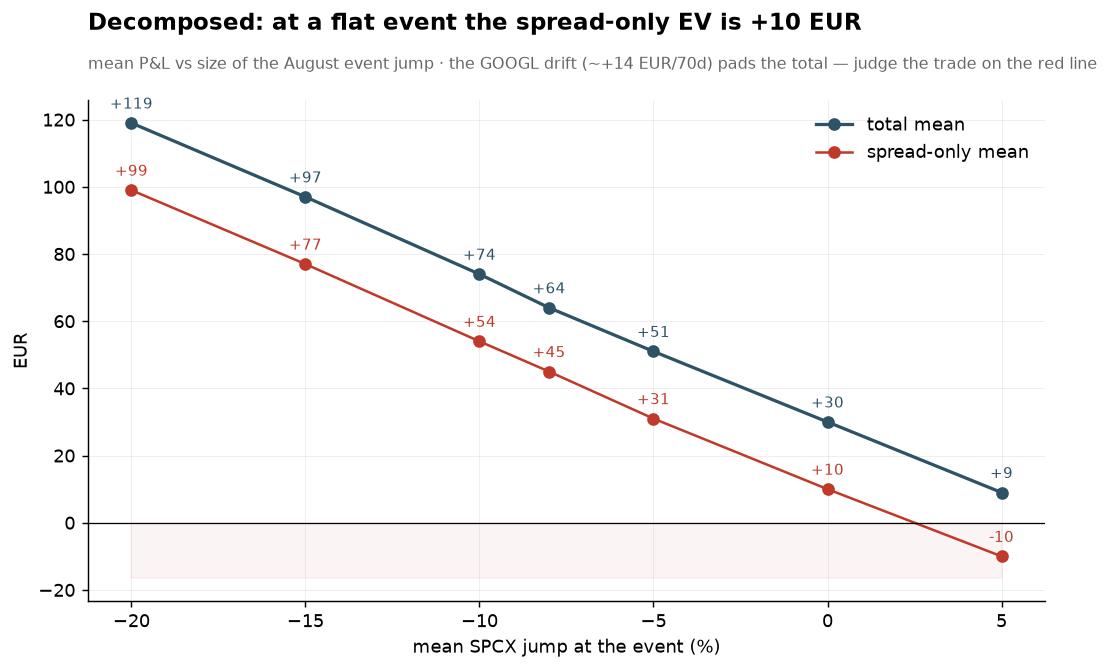

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5))
x = [-20, -15, -10, -8, -5, 0, 5]
ax.axhspan(ax.get_ylim()[0], 0, color=BAD, alpha=0.0)
for col, color, lw in [("total mean", PALETTE[0], 1.8), ("spread-only mean", PALETTE[1], 1.4)]:
    y = sens[col].values
    ax.plot(x, y, marker="o", lw=lw, color=color, label=col)
    for xi, yi in zip(x, y):
        ax.annotate(f"{yi:+.0f}", (xi, yi), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8.5, color=color)
ax.axhline(0, color="black", lw=0.7)
ax.fill_between([min(x), max(x)], ax.get_ylim()[0], 0, color=BAD, alpha=0.05)
ax.legend(loc="upper right")
spread_at_zero = sens.loc["+0%", "spread-only mean"]
headline(ax, f"Decomposed: at a flat event the spread-only EV is {spread_at_zero:+.0f} EUR",
         "mean P&L vs size of the August event jump · the GOOGL drift (~+14 EUR/70d) pads the total — judge the trade on the red line")
ax.set_xlabel("mean SPCX jump at the event (%)"); ax.set_ylabel("EUR")
fig.savefig("../assets/chart_sensitivity.png", bbox_inches="tight"); plt.show()

## Operational conclusions

1. The spread hard cap holds on 10,000 paths: losses beyond the structural cap come only from the equity tranche (market beta), never from the derivative.
2. **Judge the trade on the spread-only line.** The total-portfolio mean is padded by the GOOGL drift assumption; the decomposition shows the spread's own EV and where it crosses zero. Under these MC priors (70% vol, fat tails) the crossover sits near a flat event — more favorable than the hand-math breakeven (P≥44%) because fat tails make deep-ITM outcomes likelier than lognormal intuition suggests. Both are PRIOR-dependent: the real IV (late June) decides.
3. The left tail (ES95) is dominated by the equity tranche: to shrink it, cut equity, not the spread.
4. **Update parameters with real data** once SPCX trades: `spcx_s0`, `spcx_vol` (from listed-option IV), real `debit`.